In [91]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Ниже представлен EDA по нашему хакатону, мы заранее разбили данные нам письма на группы и решили проанализировать их по отдельности и найти закономерности как классифицировать письмо

Для начала сделаем функцию которая возвращает словарь значений письма

In [92]:
def parse(text):
    data_for_class = {}
    lines = text.splitlines()
    properties = ['To', 'From', 'Date', 'Subject', 'Body']
    for x in properties:
        data_for_class[x] = None

    data_for_class['Body'] = ''

    for i in range(len(lines)):
        line = lines[i]
        if line.count(':') == 1:
            line_split = line.split(':')
            key = line_split[0]
            value = line_split[1]
        elif line.count(':') == 2:
            line_split = line.split(':')
            key = line_split[0]
            value = line_split[1] + ':' + line_split[2] 
        else:
            data_for_class['Body'] += line + '\n'
            continue
        if key == 'To' or key == 'Кому':
            data_for_class['To'] = value.strip()
        elif key == 'From' or key == 'От кого':
            data_for_class['From'] = value.strip()
        elif key == 'Date' or key == 'Дата':
            data_for_class['Date'] = value.strip()
        elif key == 'Subject' or key == 'Тема':
            data_for_class['Subject'] = value.strip()
        else:
            data_for_class['Body'] += line + '\n'

    data_for_class['Body'] = data_for_class['Body'].strip()
    return data_for_class

    

Начнем с самого интересного - спама :)

In [93]:

# Спам
spam_path = Path('/Users/nicolas/Downloads/Письма 2/Спам')
body_spam = []
i = 0
lenght = 0
for email_file in spam_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    tmp_body = parse(text)['Body']
    body_spam.extend(tmp_body.lower().split())
    i += 1
    lenght += len(tmp_body)

print('Средняя длина текста: ' + str(lenght / i))
print('Часто встречающиеся слова:')
print(pd.Series(body_spam).value_counts().head(30))

Средняя длина текста: 209.0
Часто встречающиеся слова:
для                                 5
по                                  4
и                                   4
перейдите                           3
вложении:                           3
screenshot.png                      3
введите                             3
ссылке:                             3
во                                  3
на                                  3
ваш                                 3
часа.                               2
через                               2
аккаунт                             2
немедленно                          2
вы                                  2
будет                               2
поздравляем!                        2
с                                   2
это                                 2
карты.                              2
банковской                          2
данные                              2
http://totally-not-spam.ru/prize    2
приза                            

Дальше смотрим инциденты

In [94]:
inc_path = Path('/Users/nicolas/Downloads/Письма 2/Входящие/Инцеденты')
body_inc = []
i = 0
lenght = 0
for email_file in inc_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    tmp_body = parse(text)['Body']
    body_inc.extend(tmp_body.lower().split())
    i += 1
    lenght += len(tmp_body)

print('Средняя длина текста: ' + str(lenght / i))
print('Часто встречающиеся слова:')
print(pd.Series(body_inc).value_counts().head(30))

Средняя длина текста: 196.86206896551724
Часто встречающиеся слова:
не                  30
после               16
—                   15
день.               11
обновления          10
добрый               9
уже                  9
у                    9
с                    9
коллеги,             8
contract_v2.docx     8
прикрепил:           8
файл:                8
error_log.txt        8
отдела               7
при                  7
ошибка               7
появляется           7
перестал             7
если                 6
к                    6
вам                  6
перенаправьте,       6
вопрос               6
пожалуйста.          6
заявки:              6
id                   6
hi,                  6
утреннего            5
открываться          5
Name: count, dtype: int64


Просьбы и запросы

In [95]:
req_path = Path('/Users/nicolas/Downloads/Письма 2/Входящие/Просьбы и запросы')
body_req = []
i = 0
lenght = 0
for email_file in req_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    tmp_body = parse(text)['Body']
    body_req.extend(tmp_body.lower().split())
    i += 1
    lenght += len(tmp_body)

print('Средняя длина текста: ' + str(lenght / i))
print('Часто встречающиеся слова:')
print(pd.Series(body_req).value_counts().head(30))

Средняя длина текста: 173.02941176470588
Часто встречающиеся слова:
на                21
к                 21
прошу             18
с                 15
доступ            15
—                 13
не                12
и                 11
файл:             10
error_log.txt     10
здравствуйте!     10
в                  9
нужно              8
коллеги,           8
день.              7
добрый             7
подготовить        7
привет!            7
для                7
iphone             6
уважением,         6
у                  6
otpravleno         6
уже                6
s                  6
screenshot.png     5
hi,                5
вложении:          5
во                 5
наталья            5
Name: count, dtype: int64


Документы : финансы

In [96]:

fin_path = Path('/Users/nicolas/Downloads/Письма 2/Входящие/Документы : финансы')
body_fin = []
i = 0
lenght = 0
for email_file in fin_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    tmp_body = parse(text)['Body']
    body_fin.extend(tmp_body.lower().split())
    i += 1
    lenght += len(tmp_body)

print('Средняя длина текста: ' + str(lenght / i))
print('Часто встречающиеся слова:')
print(pd.Series(body_fin).value_counts().head(30))

Средняя длина текста: 158.93333333333334
Часто встречающиеся слова:
и                 7
в                 7
invoice.pdf       7
вложение:         7
заявки:           6
id                6
до                6
не                6
—                 5
iphone            5
s                 5
по                5
оплата            5
просим            5
во                5
otpravleno        5
к                 4
оплаты            4
за                4
здравствуйте!     4
если              4
спасибо.          4
с                 3
ещё               3
системе           3
направляем        3
прошу             3
screenshot.png    3
вложении:         3
день.             3
Name: count, dtype: int64


Черновики

In [97]:
draft_path = Path('/Users/nicolas/Downloads/Письма 2/Черновики')
body_draft = []
i = 0
lenght = 0
for email_file in draft_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    tmp_body = parse(text)['Body']
    body_draft.extend(tmp_body.lower().split())
    i += 1
    lenght += len(tmp_body)

print('Средняя длина текста: ' + str(lenght / i))
print('Часто встречающиеся слова:')
print(pd.Series(body_draft).value_counts().head(30))

Средняя длина текста: 42.0
Часто встречающиеся слова:
коллеги,    1
привет!     1
???         1
p.s.        1
это         1
уже         1
второй      1
запрос      1
по          1
данной      1
теме.       1
id          1
заявки:     1
#92213      1
Name: count, dtype: int64


Все письма

In [98]:
other_path = Path('/Users/nicolas/Downloads/Письма 2/Входящие/Прочее')
all_paths = [spam_path, inc_path, req_path, fin_path, other_path, draft_path]
body_all = []
i = 0
lenght = 0

for path in all_paths:
    for email_file in path.glob('*.txt'):
        text = email_file.read_text(encoding='utf-8', errors='ignore')
        tmp_body = parse(text)['Body']
        body_all.extend(tmp_body.lower().split())
        i += 1
        lenght += len(tmp_body)

print('Средняя длина текста: ' + str(lenght / i))
print('Часто встречающиеся слова:')
print(pd.Series(body_all).value_counts().head(30))

Средняя длина текста: 176.0952380952381
Часто встречающиеся слова:
не               57
с                38
—                35
к                34
на               33
в                30
коллеги,         29
и                26
день.            25
по               24
error_log.txt    23
файл:            23
добрый           23
заявки:          21
id               21
прошу            21
после            21
уже              19
здравствуйте!    19
привет!          18
hi,              18
invoice.pdf      18
вложение:        18
во               17
iphone           17
otpravleno       17
s                17
доступ           17
для              16
если             16
Name: count, dtype: int64


Топ отправителей по всем 

In [99]:
all_paths = [spam_path, inc_path, req_path, fin_path, other_path, draft_path]
all_senders = []

for path in all_paths:
    for email_file in path.glob('*.txt'):
        text = email_file.read_text(encoding='utf-8', errors='ignore')
        sender = parse(text)['From']
        if sender:
            all_senders.append(sender)

print('Топ отправителей:')
print(pd.Series(all_senders).value_counts().head(20))

Топ отправителей:
Светлана Попова <s.popova@company.ru>       10
Тимур Андреев <t.andreev@company.ru>         6
Людмила Захарова <l.zaharova@corp.local>     5
no-reply <no-reply@monitoring.internal>      4
Павел Соколов <p.sokolov@vendor.net>         4
Ольга Белова <o.belova@client.biz>           4
Елена Новикова <e.novikova@corp.local>       4
Виктор Громов <v.gromov@partner.ru>          4
k.morozov@company.ru                         3
Мария Смирнова <m.smirnova@company.ru>       3
Kate Brown <k.brown@extern.org>              3
noreply@jira.internal                        3
a.kozlov@company.ru                          3
John Smith <john.smith@globaltech.com>       3
Юлия Кириллова <yu.kirillova@company.ru>     3
alerts <alerts@grafana.internal>             3
Михаил Сидоров <m.sidorov@company.ru>        3
Анна Фёдорова <a.fedorova@company.ru>        2
no-reply@monitoring.internal                 2
Кирилл Морозов <k.morozov@company.ru>        2
Name: count, dtype: int64


Спам - отправители

In [100]:
spam_senders = []
for email_file in spam_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    sender = parse(text)['From']
    if sender:
        spam_senders.append(sender)

print('Топ отправителей:')
print(pd.Series(spam_senders).value_counts().head(30))

Топ отправителей:
a.kozlov@company.ru                        2
Мария Смирнова <m.smirnova@company.ru>     1
Сергей Волков <s.volkov@partner.ru>        1
no-reply <no-reply@monitoring.internal>    1
t.andreev@company.ru                       1
Name: count, dtype: int64


Инциденты - отправители

In [101]:
inc_senders = []
for email_file in inc_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    sender = parse(text)['From']
    if sender:
        inc_senders.append(sender)

print('Топ отправителей:')
print(pd.Series(inc_senders).value_counts().head(30))

Топ отправителей:
Тимур Андреев <t.andreev@company.ru>        3
Елена Новикова <e.novikova@corp.local>      3
Светлана Попова <s.popova@company.ru>       2
Михаил Сидоров <m.sidorov@company.ru>       2
a.fedorova@company.ru                       2
alerts <alerts@grafana.internal>            2
Павел Соколов <p.sokolov@vendor.net>        1
noreply@jira.internal                       1
Наталья Лебедева <n.lebedeva@corp.local>    1
s.volkov@partner.ru                         1
Иван Петров <i.petrov@company.ru>           1
v.gromov@partner.ru                         1
alerts@grafana.internal                     1
Виктор Громов <v.gromov@partner.ru>         1
o.belova@client.biz                         1
John Smith <john.smith@globaltech.com>      1
a.kozlov@company.ru                         1
Мария Смирнова <m.smirnova@company.ru>      1
p.sokolov@vendor.net                        1
Дмитрий Орлов <d.orlov@corp.local>          1
d.orlov@corp.local                          1
Name: count, dty

Просьбы и запросы - отправители

In [102]:
req_senders = []
for email_file in req_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    sender = parse(text)['From']
    if sender:
        req_senders.append(sender)

print('Топ отправителей:')
print(pd.Series(req_senders).value_counts().head(30))

Топ отправителей:
Светлана Попова <s.popova@company.ru>       6
Людмила Захарова <l.zaharova@corp.local>    3
no-reply <no-reply@monitoring.internal>     2
alerts                                      2
Тимур Андреев <t.andreev@company.ru>        2
Кирилл Морозов <k.morozov@company.ru>       2
Елена Новикова <e.novikova@corp.local>      1
Виктор Громов <v.gromov@partner.ru>         1
o.belova@client.biz                         1
Павел Соколов <p.sokolov@vendor.net>        1
John Smith <john.smith@globaltech.com>      1
noreply@jira.internal                       1
Юлия Кириллова <yu.kirillova@company.ru>    1
Ольга Белова <o.belova@client.biz>          1
s.popova@company.ru                         1
Михаил Сидоров <m.sidorov@company.ru>       1
Алексей Козлов <a.kozlov@company.ru>        1
Анна Фёдорова <a.fedorova@company.ru>       1
k.morozov@company.ru                        1
no-reply@monitoring.internal                1
Kate Brown <k.brown@extern.org>             1
v.gromov@partner

Документы : финансы - отправители

In [103]:
fin_senders = []
for email_file in fin_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    sender = parse(text)['From']
    if sender:
        fin_senders.append(sender)

print('Топ отправителей:')
print(pd.Series(fin_senders).value_counts().head(30))

Топ отправителей:
Юлия Кириллова <yu.kirillova@company.ru>    2
Павел Соколов <p.sokolov@vendor.net>        2
Kate Brown <k.brown@extern.org>             2
n.lebedeva@corp.local                       1
Ольга Белова <o.belova@client.biz>          1
Сергей Волков <s.volkov@partner.ru>         1
noreply@jira.internal                       1
yu.kirillova@company.ru                     1
k.morozov@company.ru                        1
Наталья Лебедева <n.lebedeva@corp.local>    1
Тимур Андреев <t.andreev@company.ru>        1
Анна Фёдорова <a.fedorova@company.ru>       1
Name: count, dtype: int64


Черновики - отправители

In [104]:
draft_senders = []
for email_file in draft_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    sender = parse(text)['From']
    if sender:
        draft_senders.append(sender)

print('Топ отправителей:')
print(pd.Series(draft_senders).value_counts().head(30))

Топ отправителей:
k.morozov@company.ru    1
Name: count, dtype: int64


Все письма - кому

In [105]:
all_to = []
i = 0
lenght = 0

for path in all_paths:
    for email_file in path.glob('*.txt'):
        text = email_file.read_text(encoding='utf-8', errors='ignore')
        to = parse(text)['To']
        if to:
            all_to.append(to)

print('Топ получателей по всем письмам:')
print(pd.Series(all_to).value_counts().head(30))

Топ получателей по всем письмам:
it-support@company.ru    76
Name: count, dtype: int64


Как видно все письма приходят одному пользователю значит исследовать это дальше безполезно

Все письма - тема

In [106]:
all_subj = []
for path in all_paths:
    for email_file in path.glob('*.txt'):
        text = email_file.read_text(encoding='utf-8', errors='ignore')
        subj = parse(text)['Subject']
        if subj:
            all_subj.append(subj)

print('Топ тем по всем письмам:')
print(pd.Series(all_subj).value_counts().head(30))

Топ тем по всем письмам:
Уточнение по оплате договора                                3
Запрос от внешнего пользователя                             3
Заявка на отпуск                                            2
Неисправность оборудования: ноутбук                         2
Нет доступа к GitLab после перевода                         2
Приглашение на демо                                         2
[INFO] Плановый отчёт мониторинга                           2
Изменение графика работы                                    2
Запрос доступа к VPN                                        2
Массовый сбой авторизации                                   2
Требуется срочная верификация аккаунта                      2
Финальная версия: договор                                   2
Не запускается антивирус                                    2
Запрос доступа к почта                                      2
Запрос доступа к система согласования                       1
Счёт на оплату №8141                         

Спам - тема

In [107]:
spam_subj = []
for email_file in spam_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    subj = parse(text)['Subject']
    if subj:
        spam_subj.append(subj)

print('Топ тем - Спам:')
print(pd.Series(spam_subj).value_counts().head(30))

Топ тем - Спам:
Re: Exclusive offer — limited time        1
Требуется срочная верификация аккаунта    1
Вы выиграли iPhone 15!                    1
Срочно подтвердите личность               1
Name: count, dtype: int64


Инциденты - тема

In [108]:
inc_subj = []
for email_file in inc_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    subj = parse(text)['Subject']
    if subj:
        inc_subj.append(subj)

print('Топ тем - Инциденты:')
print(pd.Series(inc_subj).value_counts().head(30))

Топ тем - Инциденты:
Не запускается антивирус                                2
Массовый сбой авторизации                               2
URGENT: BI-система не отвечает                          1
Падает корпоративный портал, работа остановлена         1
Падает Service Desk, работа остановлена                 1
Срочно: не работает Active Directory                    1
Ошибка в Adobe Reader после обновления                  1
Критический инцидент — GitLab недоступен                1
Ошибка в Excel после обновления                         1
браузер Chrome зависает при открытии                    1
Ошибка в антивирус после обновления                     1
Не могу войти в Confluence — у всех отдела              1
Финальная версия: договор                               1
Падает система согласования, работа остановлена         1
Проблема с установкой Zoom                              1
Не могу войти в почта — у всех отдела                   1
Re:                                                

Просьбы и запросы - тема

In [109]:
req_subj = []
for email_file in req_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    subj = parse(text)['Subject']
    if subj:
        req_subj.append(subj)

print('Топ тем - Просьбы и запросы:')
print(pd.Series(req_subj).value_counts().head(30))

Топ тем - Просьбы и запросы:
Запрос доступа к VPN                                        2
Приглашение на демо                                         2
Изменение графика работы                                    2
Запрос доступа к почта                                      2
Неисправность оборудования: ноутбук                         2
Заявка на отпуск                                            2
Нет доступа к GitLab после перевода                         2
Нужны права в 1C для нового сотрудника                      1
Статус задач — нужен созвон                                 1
Запрос доступа к Confluence                                 1
Нужны права в VPN для нового сотрудника                     1
Больничный лист                                             1
Запрос доступа к система согласования                       1
Неисправность оборудования: гарнитура                       1
URGENT: Больничный лист                                     1
URGENT: Запрос от внешнего пользователя  

Документы : финансы - тема

In [110]:
fin_subj = []
for email_file in fin_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    subj = parse(text)['Subject']
    if subj:
        fin_subj.append(subj)

print('Топ тем - Документы : финансы:')
print(pd.Series(fin_subj).value_counts().head(30))

Топ тем - Документы : финансы:
Уточнение по оплате договора           3
Правки к инструкцияу                   1
Правки к техническое заданиеу          1
Счёт на оплату №4008                   1
Счёт на оплату №8141                   1
Финальная версия: договор              1
Закрывающие документы за июнь          1
Инструкция на согласование             1
Fwd: Акт выполненных работ — апрель    1
Закрывающие документы за декабрь       1
Закрывающие документы за март          1
Финальная версия: инструкция           1
Name: count, dtype: int64


Черновики - тема

In [111]:
draft_subj = []
for email_file in draft_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    subj = parse(text)['Subject']
    if subj:
        draft_subj.append(subj)

print('Топ тем - Черновики:')
print(pd.Series(draft_subj).value_counts().head(30))

Топ тем - Черновики:
Проблема    1
Name: count, dtype: int64


Теперь посмотрим и наглядно увидим какие слова указывают на определенный класс, вот как будет выглядеть DataFrame который мы будем использовать, в колонке слова будут слова, в частоте лежит то насколько часто слово встертилось именно в этом классе

In [112]:
class_series = pd.Series(body_spam).value_counts().head(30)
all_series = pd.Series(body_all).value_counts()
words = class_series.index.tolist()

df = pd.DataFrame({
    'word': words,
    'freq': [class_series[w] / all_series[w] for w in words]
})

df

,word,freq
0,для,0.312500
1,по,0.166667
2,и,0.153846
3,перейдите,1.000000
4,вложении:,0.214286
5,screenshot.png,0.214286
6,введите,1.000000
7,ссылке:,0.750000
8,во,0.176471
9,на,0.090909


Тепрерь для наглядности мы это визуализируем

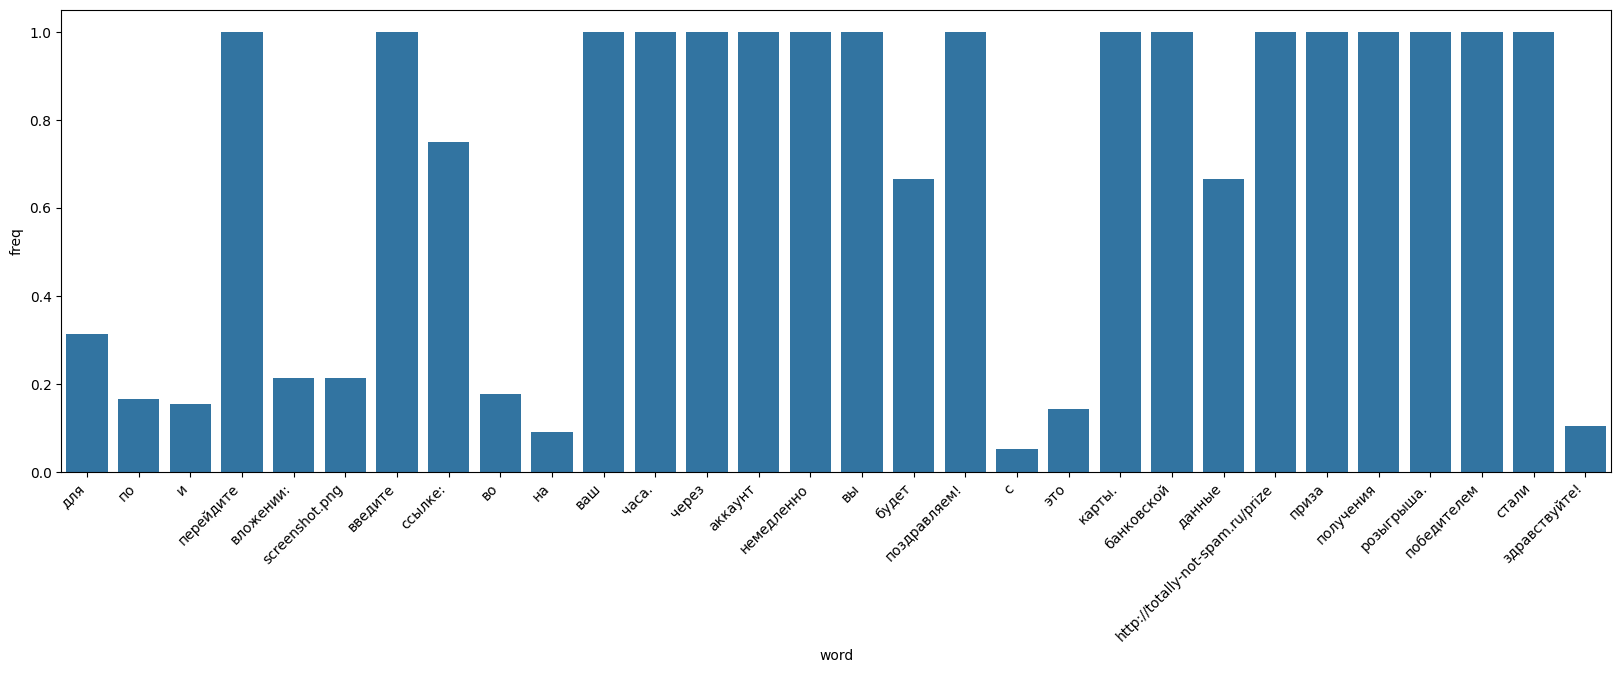

In [113]:
plt.figure(figsize=(20, 6))
sns.barplot(data=df, x='word', y='freq')
plt.xticks(rotation=45, ha='right')
plt.show()

Не хочется выдумывать что то сложное, предлагаю считать слово относящимся к конкретному классу, если больше половины его вхождений приходится на конкретный класс, однако из за того что данных очень мало некоторые слова могут попасть по ошибке и я буду их отбирать лично так как наша программа должна взаимодействовать и с новыми письмами

Вот получившиеся ключевые слова но некоторые из них я бы не стал определять как слова только для спама, например 'вы'

In [114]:
spam_keywords_old = ['перейдите', 'введите', 'ссылке', 'ваш', 'часа', 'через', 'аккаунт', 'немедленно', 'вы', 'будет', 'поздравляем', 'карты', 'банковской', 
                 'данные', 'http://totally-not-spam.ru/prize', 'приза', 'получения', 'розыгрыша', 'победителем', 'стали']

In [115]:
spam_keywords = ['перейдите', 'введите', 'ссылке', 'через', 'аккаунт', 'немедленно', 'поздравляем', 'карты', 'банковской', 
                 'данные', 'http://totally-not-spam.ru/prize', 'приза', 'получения', 'розыгрыша', 'победителем', 'стали']

Я выбрал эти слова ведь остальные могли просто чаще встречаться из за малого количества данных

Я не буду также подробно расписывать остальные, ведь логика будет прежней

Инциденты

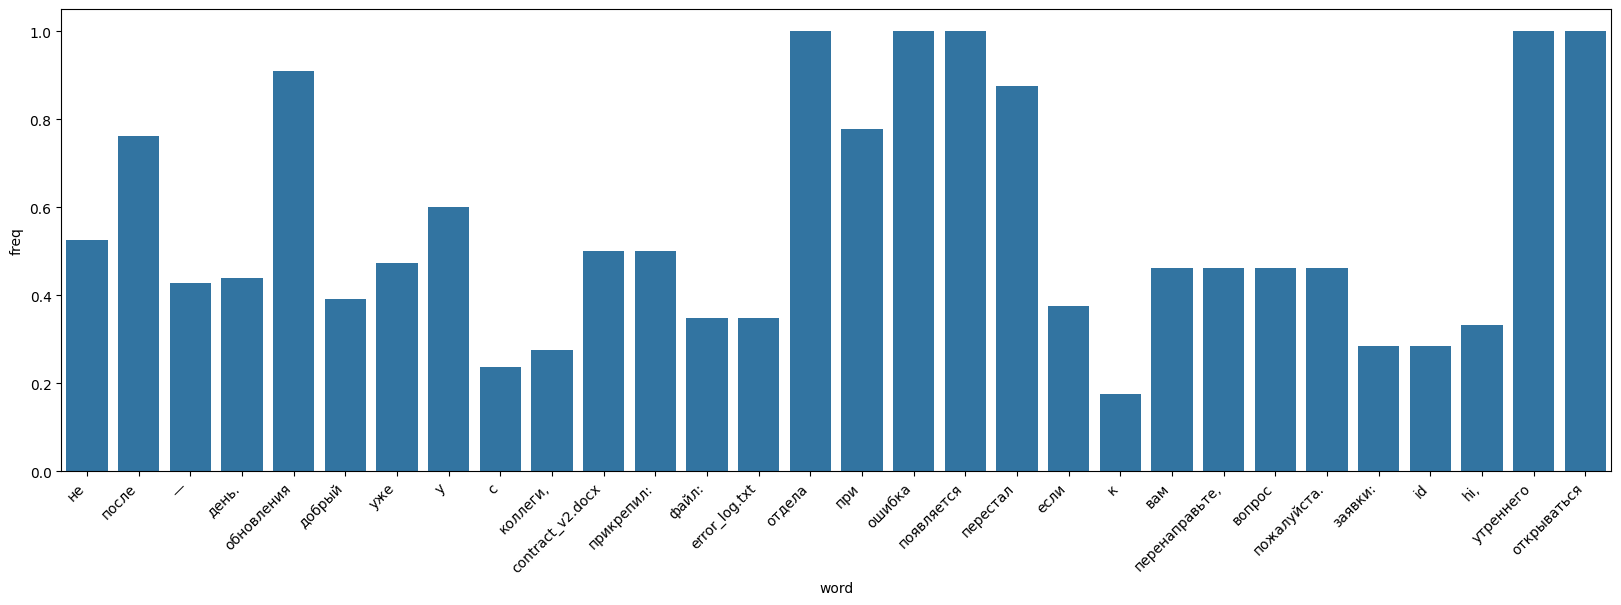

In [116]:
class_series = pd.Series(body_inc).value_counts().head(30)
all_series = pd.Series(body_all).value_counts()
words = class_series.index.tolist()

df_inc = pd.DataFrame({
    'word': words,
    'freq': [class_series[w] / all_series[w] for w in words]
})

plt.figure(figsize=(20, 6))
sns.barplot(data=df_inc, x='word', y='freq')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
incidents_keywords = ['после', 'обновления', 'отдела', 'при', 'ошибка',
                       'появляется', 'перестал', 'утреннего', 'открываться']

Просьбы и запросы

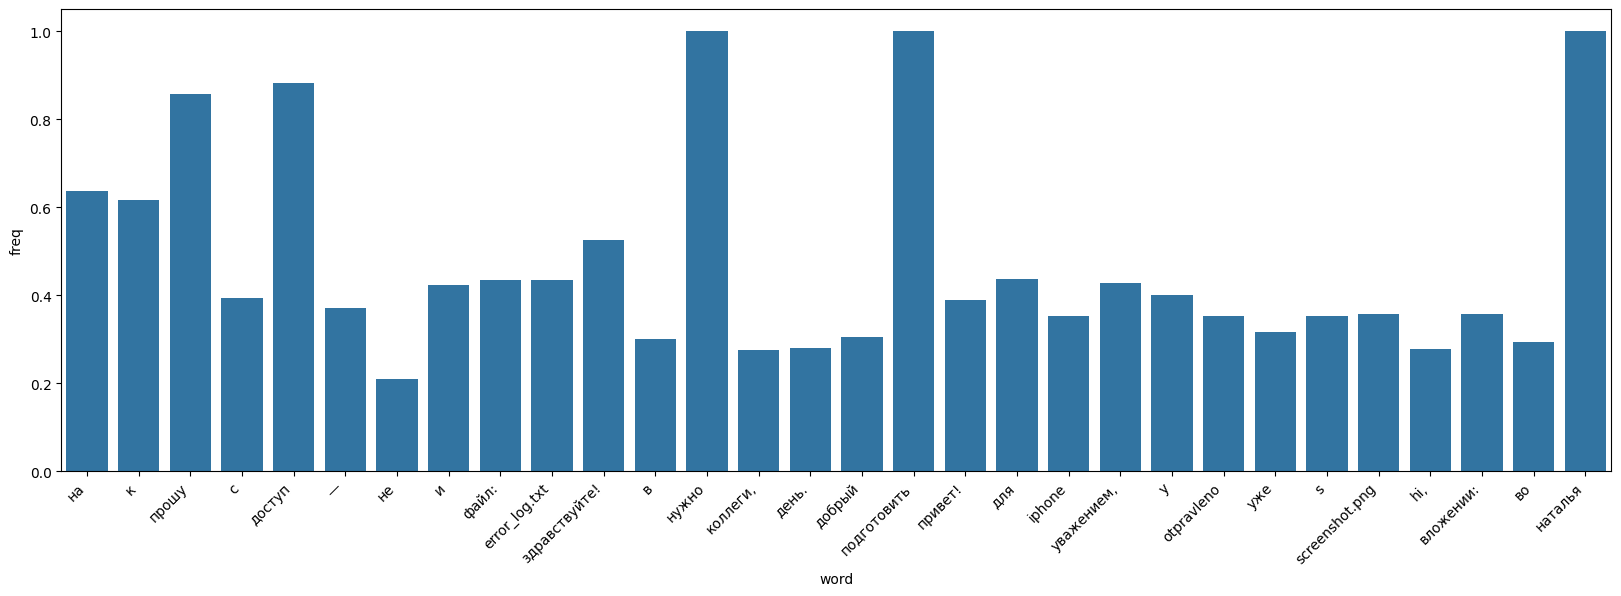

In [118]:
class_series = pd.Series(body_req).value_counts().head(30)
words = class_series.index.tolist()

df_req = pd.DataFrame({
    'word': words,
    'freq': [class_series[w] / all_series[w] for w in words]
})

plt.figure(figsize=(20, 6))
sns.barplot(data=df_req, x='word', y='freq')
plt.xticks(rotation=45, ha='right')
plt.show()


In [119]:
requests_keywords = ['прошу', 'доступ', 'нужно', 'подготовить', 'наталья']

Предвещая вопросы, я оставил Наталья потому что она похоже отвечает за запросы, возможно она работает в поддержке :)

Документы : финансы

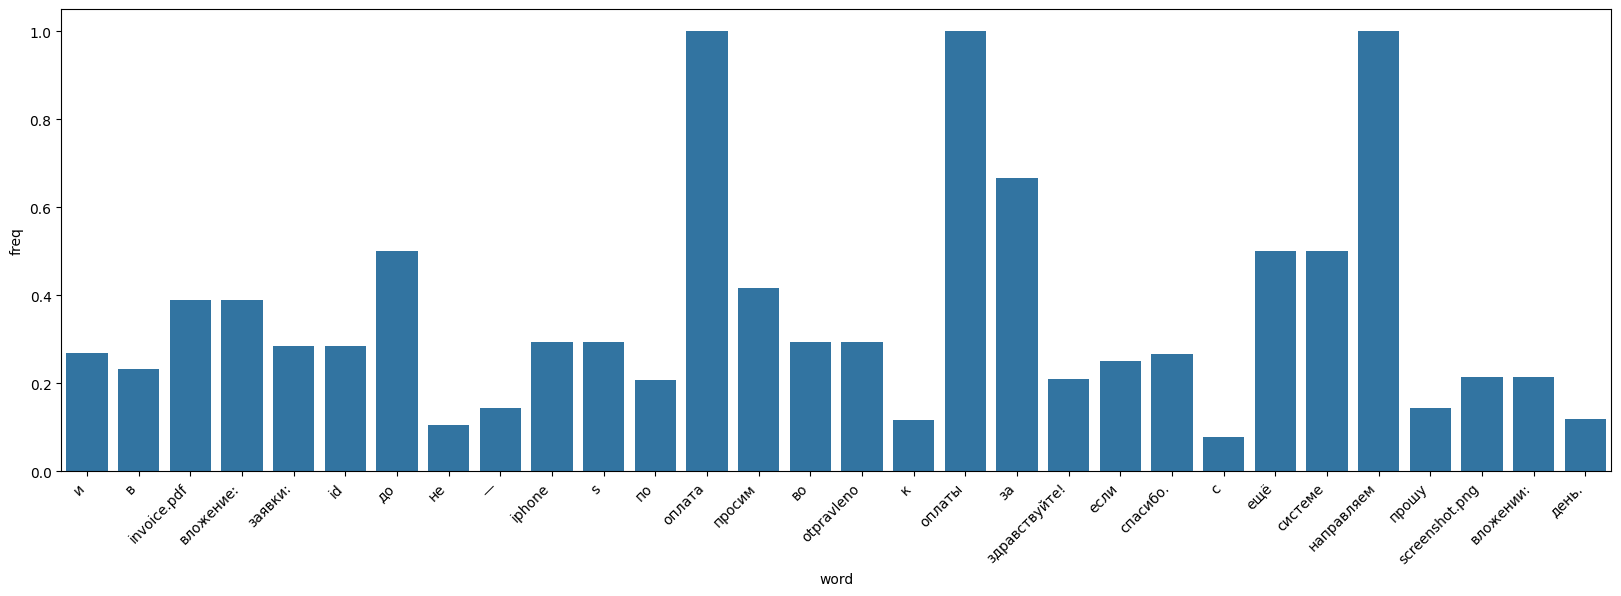

In [120]:
class_series = pd.Series(body_fin).value_counts().head(30)
words = class_series.index.tolist()

df_fin = pd.DataFrame({
    'word': words,
    'freq': [class_series[w] / all_series[w] for w in words]
})

plt.figure(figsize=(20, 6))
sns.barplot(data=df_fin, x='word', y='freq')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
finance_keywords = ['оплата', 'оплаты', 'направляем']

Не вижу смысла смотреть черновики ведь у нас только одно такое письмо не считая пустого

Теперь посмотрим на отправителей

Спам 

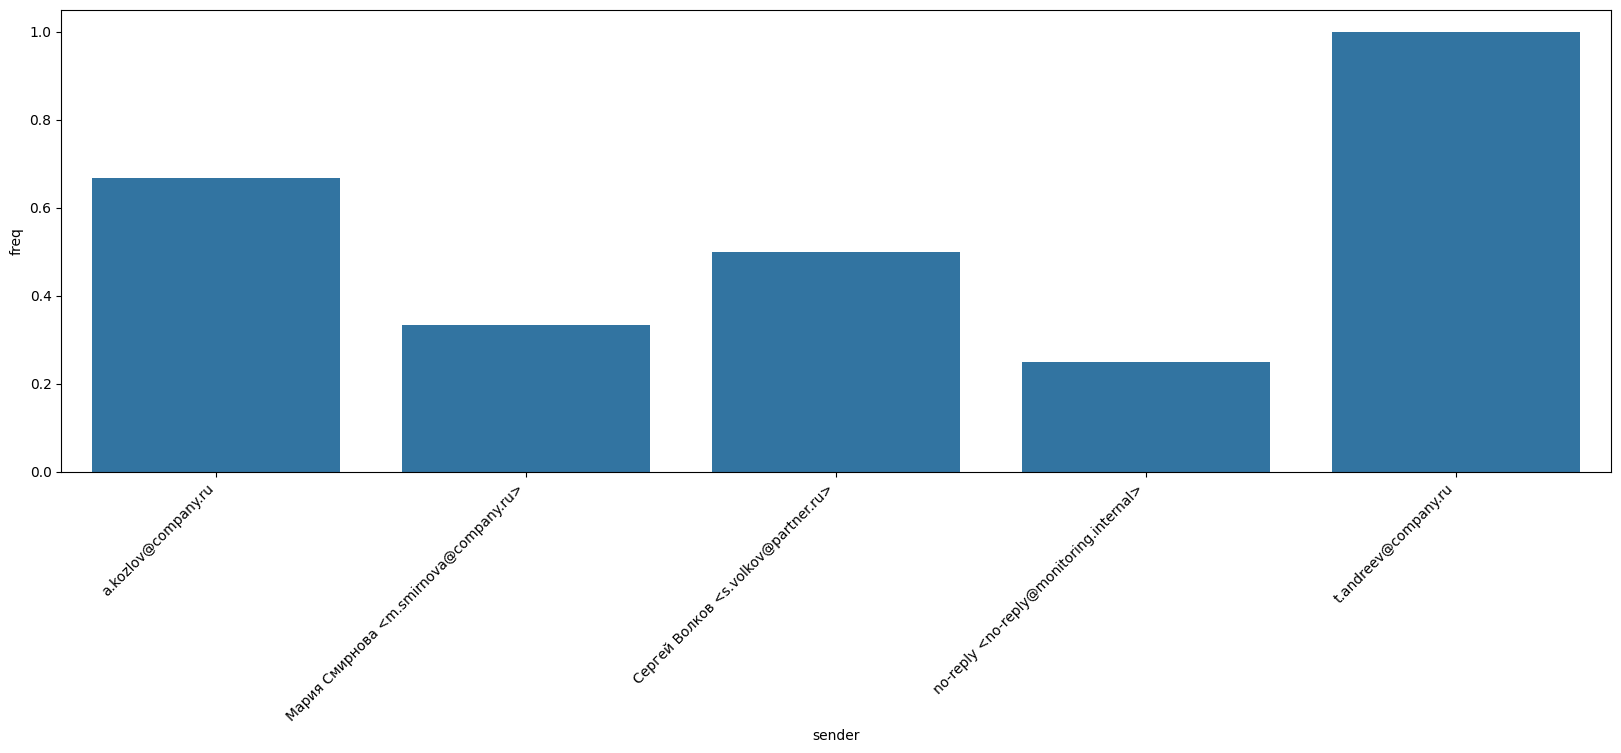

In [122]:
class_series = pd.Series(spam_senders).value_counts().head(30)
all_series = pd.Series(all_senders).value_counts()
words = class_series.index.tolist()

df_spam_s = pd.DataFrame({
    'sender': words,
    'freq': [class_series[w] / all_series[w] for w in words]
})

plt.figure(figsize=(20, 6))
sns.barplot(data=df_spam_s, x='sender', y='freq')
plt.xticks(rotation=45, ha='right')
plt.show()

In [123]:
spam_senders = ['a.kozlov@company.ru', 't.andreev@company.ru']

Инциденты

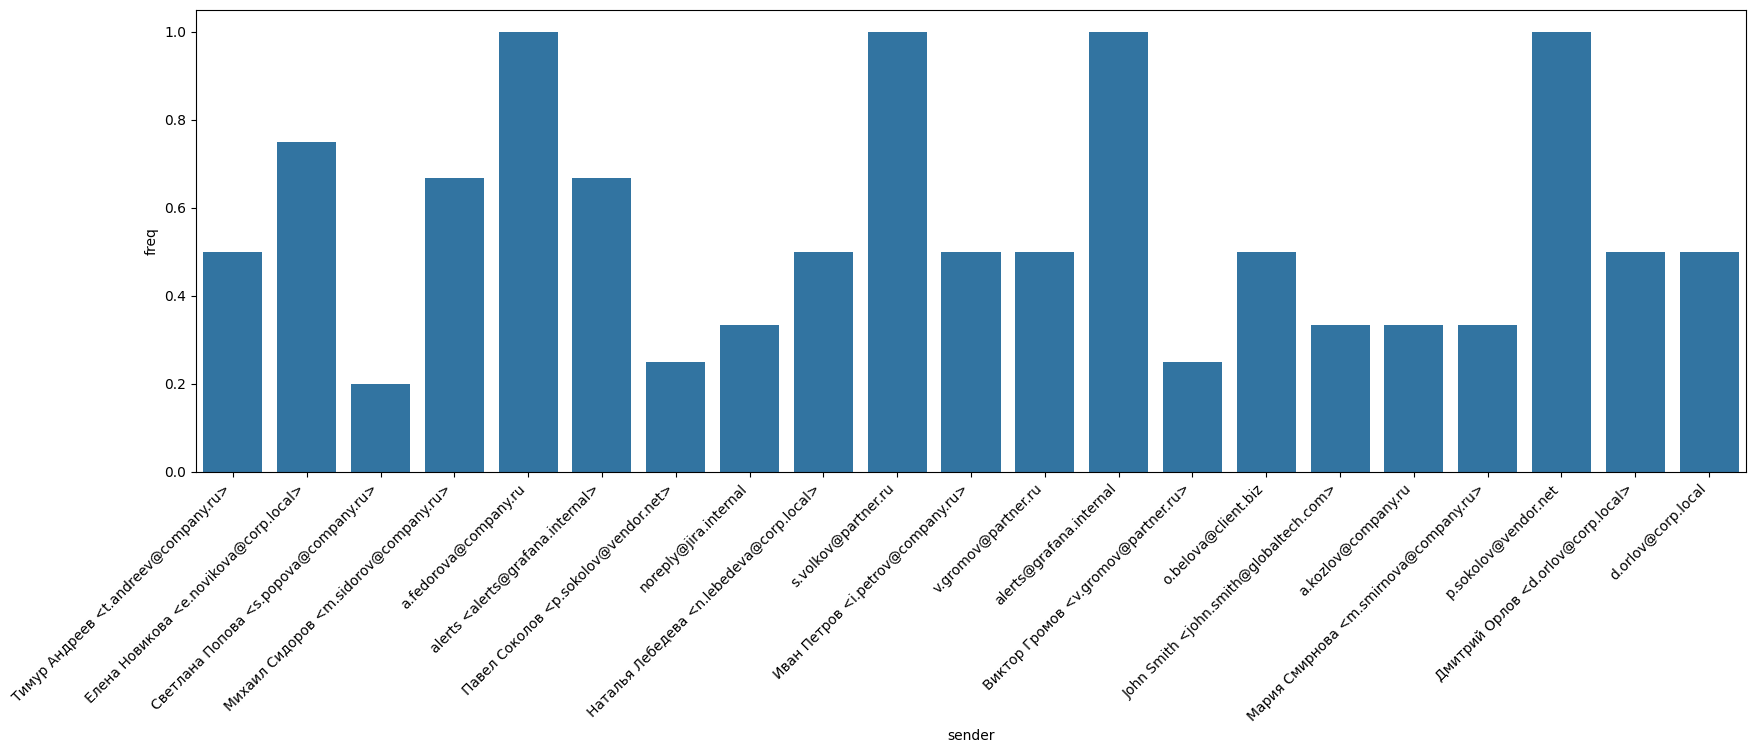

In [124]:
class_series = pd.Series(inc_senders).value_counts().head(30)
words = class_series.index.tolist()

df_inc_s = pd.DataFrame({
    'sender': words,
    'freq': [class_series[w] / all_series[w] for w in words]
})

plt.figure(figsize=(20, 6))
sns.barplot(data=df_inc_s, x='sender', y='freq')
plt.xticks(rotation=45, ha='right')
plt.show()

In [125]:
inc_senders = ['Елена Новикова <e.novikova@corp.local>', 'a.fedorova@company.ru', 
               'alerts <alerts@grafana.internal>', 'a.fedorova@company.ru', 's.volkov@partner.ru',
                 'Иван Петров <i.petrov@company.ru>', 'alerts@grafana.internal', 'p.sokolov@vendor.net']

Просьбы и запросы

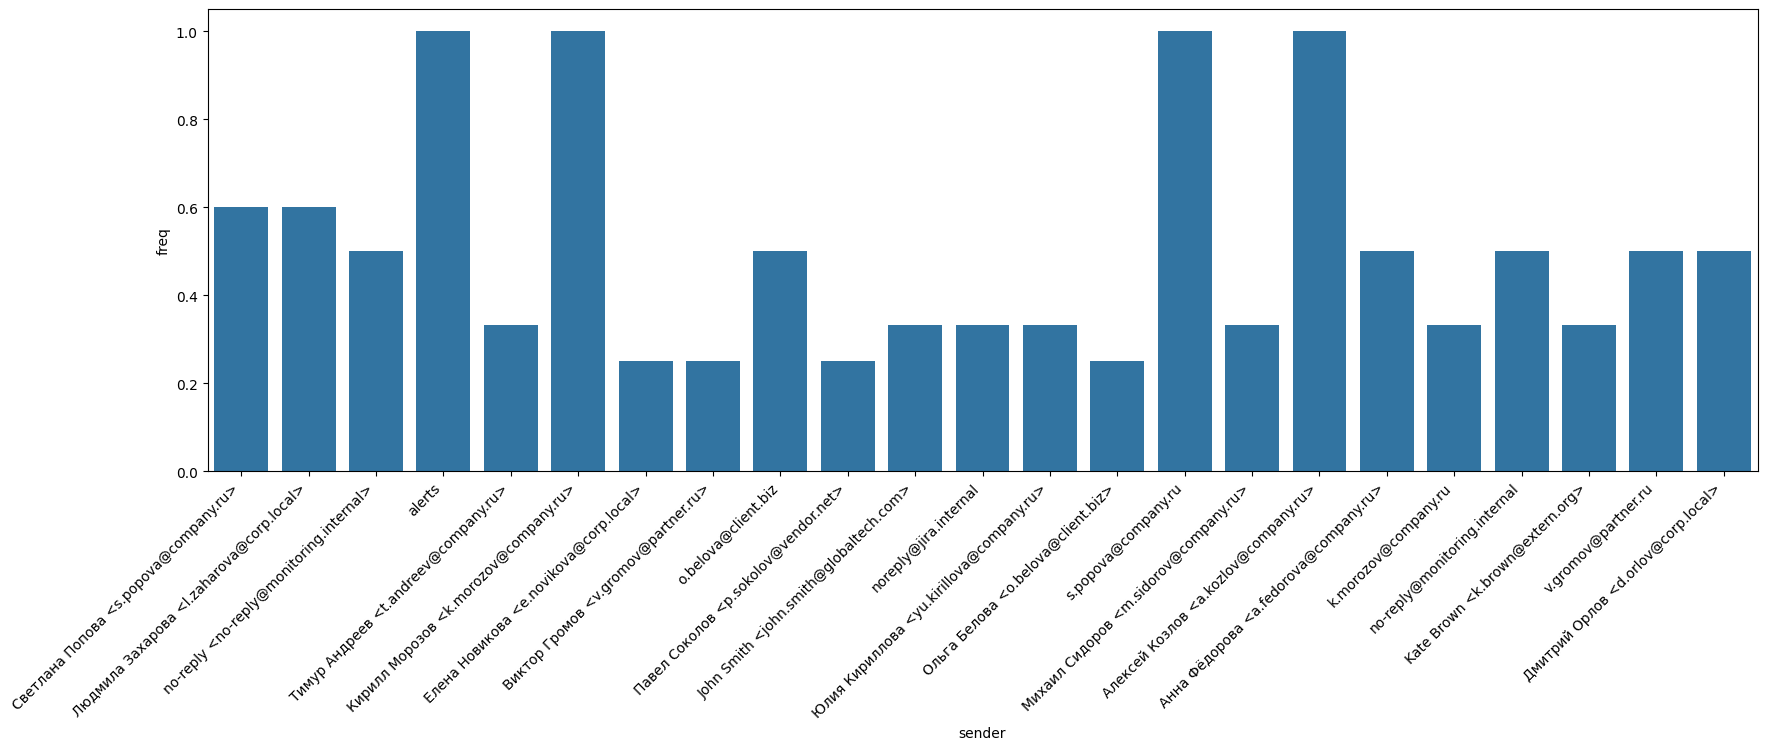

In [126]:
class_series = pd.Series(req_senders).value_counts().head(30)
words = class_series.index.tolist()

df_req_s = pd.DataFrame({
    'sender': words,
    'freq': [class_series[w] / all_series[w] for w in words]
})

plt.figure(figsize=(20, 6))
sns.barplot(data=df_req_s, x='sender', y='freq')
plt.xticks(rotation=45, ha='right')
plt.show()

In [127]:
requests_senders = ['Светлана Попова <s.popova@company.ru>', 'Людмила Захарова <l.zaharova@corp.local>',
'no-reply <no-reply@monitoring.internal>', 'alerts', 'Елена Новикова <e.novikova@corp.local>', 'o.belova@client.biz', 
'Михаил Сидоров <m.sidorov@company.ru>', 'Анна Фёдорова <a.fedorova@company.ru>', 'k.morozov@company.ru', 'Kate Brown <k.brown@extern.org>', 
'v.gromov@partner.ru', 'Дмитрий Орлов <d.orlov@corp.local>']

Документы финансы

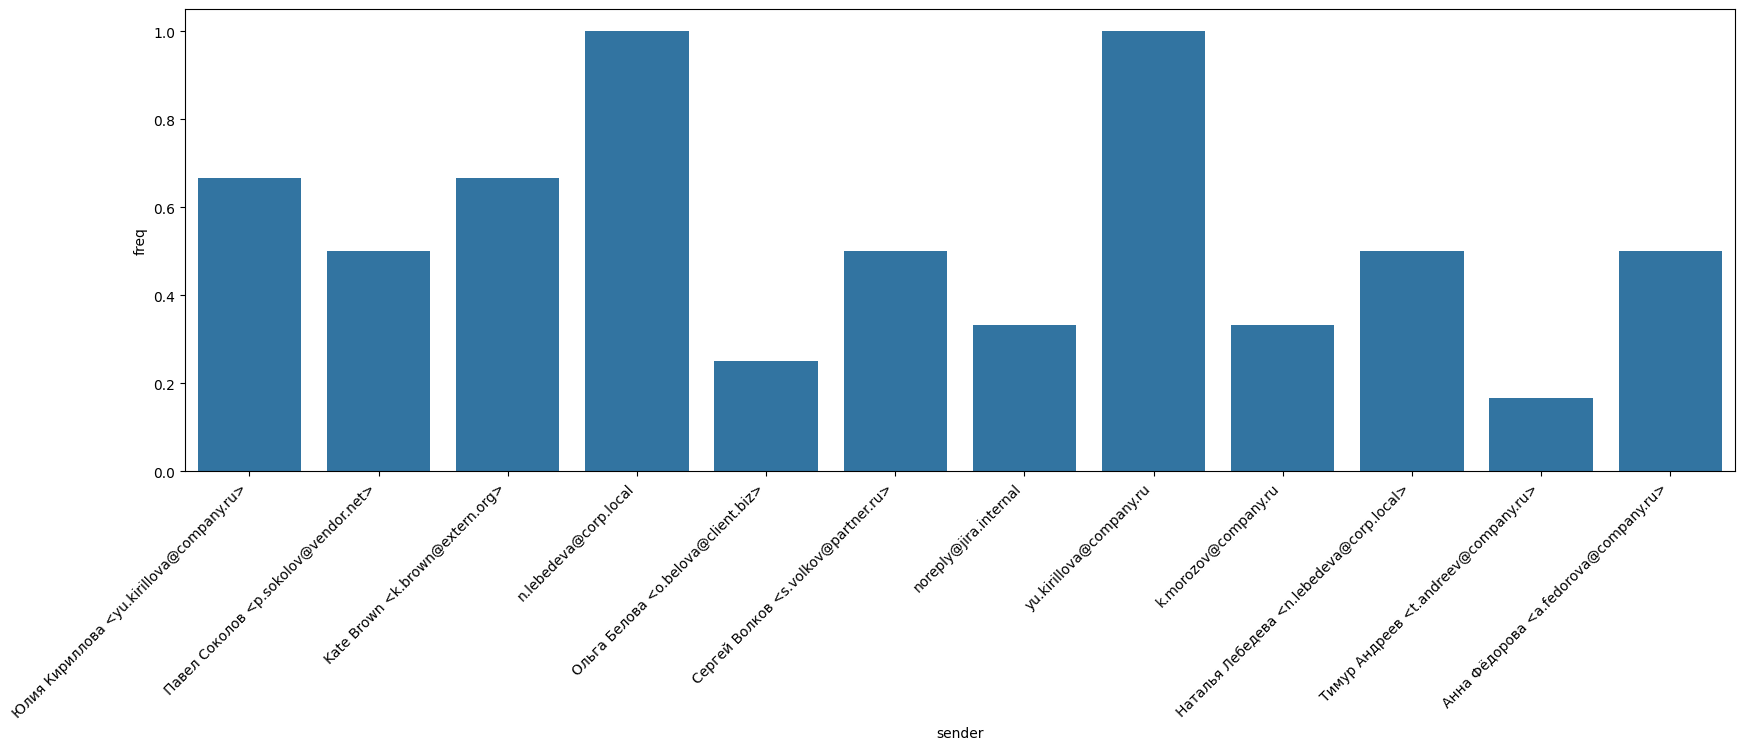

In [128]:
class_series = pd.Series(fin_senders).value_counts().head(30)
words = class_series.index.tolist()

df_fin_s = pd.DataFrame({
    'sender': words,
    'freq': [class_series[w] / all_series[w] for w in words]
})

plt.figure(figsize=(20, 6))
sns.barplot(data=df_fin_s, x='sender', y='freq')
plt.xticks(rotation=45, ha='right')
plt.show()

In [129]:
finance_senders = ['Юлия Кириллова <yu.kirillova@company.ru>', 'Kate Brown <k.brown@extern.org>', 
               'n.lebedeva@corp.local', 'yu.kirillova@company.ru', 'Наталья Лебедева <n.lebedeva@corp.local>', 'Тимур Андреев <t.andreev@company.ru>', 
               'Анна Фёдорова <a.fedorova@company.ru>']

Теперь сделаем еще более интересный анализ по часто встречающихся слов в темах

Все слова во всех темах

In [130]:
all_subj_words = []
for s in all_subj:
    all_subj_words.extend(s.lower().split())

Спам

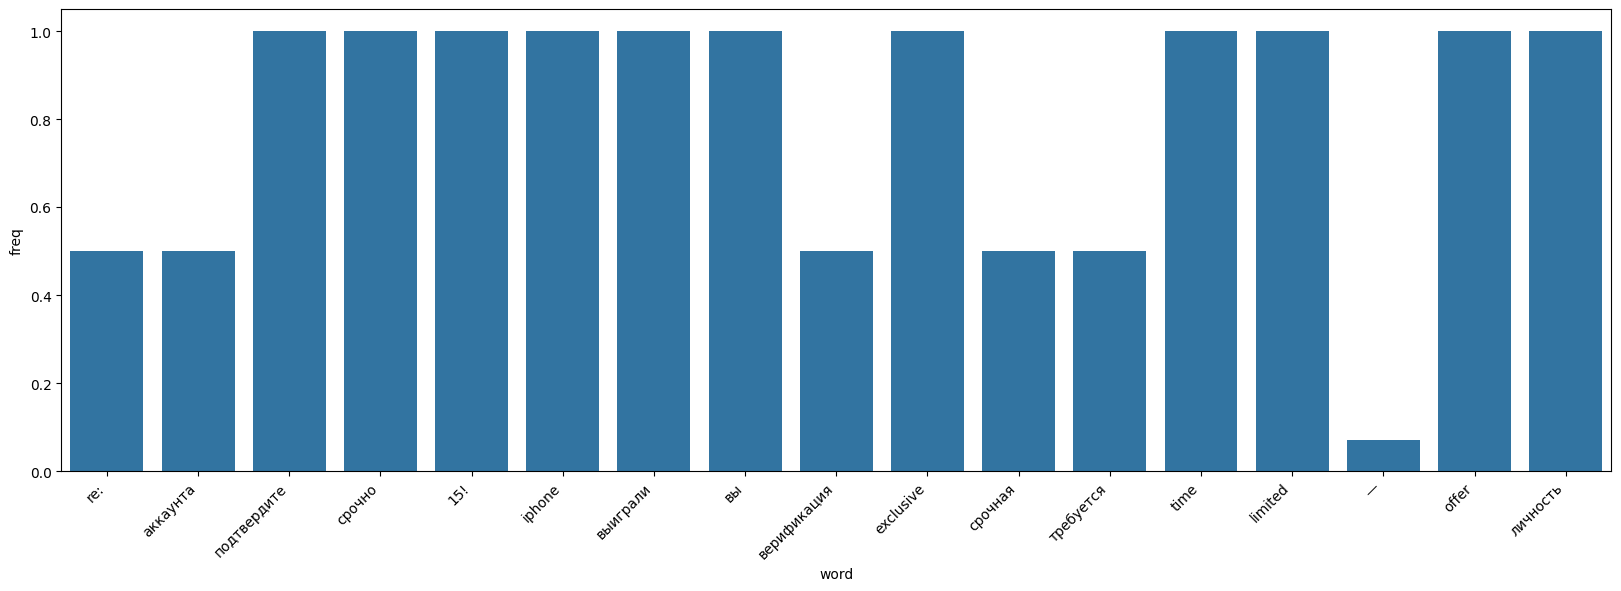

In [131]:
spam_subj_words = []
for s in spam_subj:
    spam_subj_words.extend(s.lower().split())

class_series = pd.Series(spam_subj_words).value_counts().head(30)
all_series = pd.Series(all_subj_words).value_counts()
words = class_series.index.tolist()

df = pd.DataFrame({
    'word': words,
    'freq': [class_series[w] / all_series[w] for w in words]
})

plt.figure(figsize=(20, 6))
sns.barplot(data=df, x='word', y='freq')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
spam_subject_keywords = ['подтвердите', 'срочно', '15!', 'iphone', 'выиграли', 'exclusive', 'верификация', 'time', 'limited', 'offer', 'личность']

Инциденты

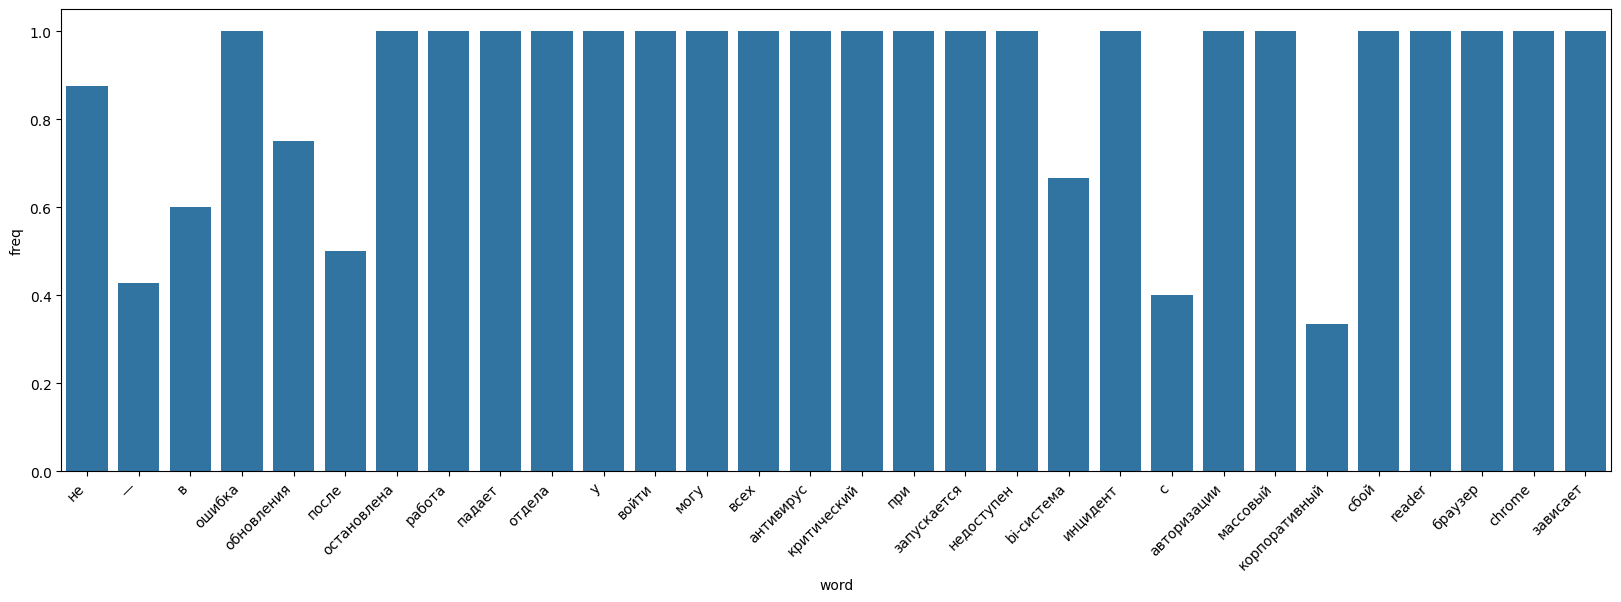

In [133]:
inc_subj_words = []
for s in inc_subj:
    inc_subj_words.extend(s.lower().split())

class_series = pd.Series(inc_subj_words).value_counts().head(30)
words = class_series.index.tolist()

df = pd.DataFrame({
    'word': words,
    'freq': [class_series[w] / all_series[w] for w in words]
})

plt.figure(figsize=(20, 6))
sns.barplot(data=df, x='word', y='freq')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
inc_subject_keywords = ['ошибка', 'обновления', 'остановлена', 'работа', 'падает', 
                        'отдела', 'войти', 'могу', 'антивирус', 'критический', 'запускается', 'недоступен',
                          'bi-система', 'инцидент', 'авторизации', 'массовый', 'сбой', 'reader', 'браузер', 'chrome', 'зависает']

Просьбы и запросы 

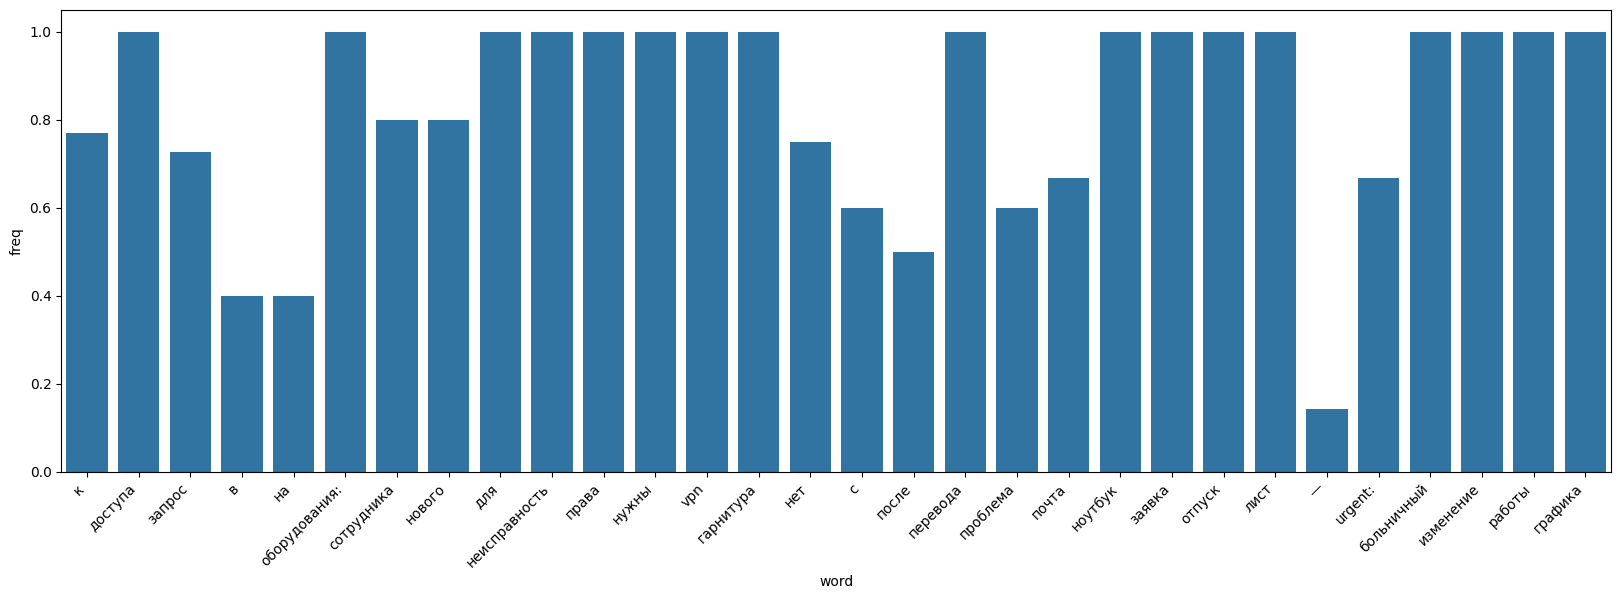

In [135]:
req_subj_words = []
for s in req_subj:
    req_subj_words.extend(s.lower().split())

class_series = pd.Series(req_subj_words).value_counts().head(30)
words = class_series.index.tolist()

df = pd.DataFrame({
    'word': words,
    'freq': [class_series[w] / all_series[w] for w in words]
})

plt.figure(figsize=(20, 6))
sns.barplot(data=df, x='word', y='freq')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
req_subject_keywords = ['доступа', 'запрос', 'оборудования:', 'сотрудника', 'нового', 
                             'неисправность', 'права', 'нужны', 'vpn', 'гарнитура', 'нет', 'после', 'перевода', 'проблема', 'почта', 
                             'ноутбук', 'заявка', 'отпуск', 'лист', 'больничный', 'изменение', 'работы', 'графика']

Документы финансы

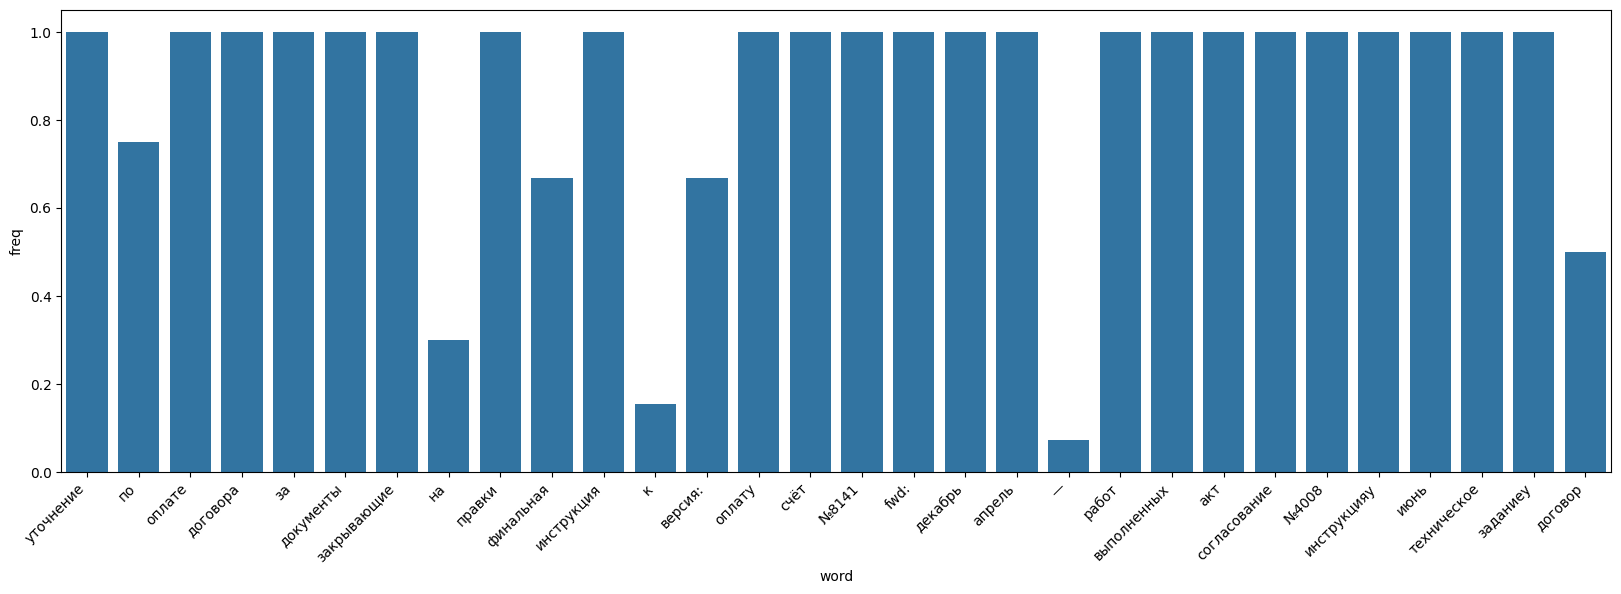

In [137]:
fin_subj_words = []
for s in fin_subj:
    fin_subj_words.extend(s.lower().split())

class_series = pd.Series(fin_subj_words).value_counts().head(30)
words = class_series.index.tolist()

df = pd.DataFrame({
    'word': words,
    'freq': [class_series[w] / all_series[w] for w in words]
})

plt.figure(figsize=(20, 6))
sns.barplot(data=df, x='word', y='freq')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
fin_subject_keywords = ['уточнение', 'оплате', 'договора', 'документы', 'закрывающие', 'правки', 'финальная', 'инструкция', 
                            'оплату', 'счёт', '№','fwd:', 'декабрь', 'апрель', 'работ', 'выполненных', 
                            'акт', 'согласование', 'инструкцияу', 'техническое', 'договор']

Теперь распределим коэфиценты для ключевых слов, будем действовать по логике сколько в среднем ключевые слова встречаются в классе

Спам

In [139]:
counts = []
for email_file in spam_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    words = parse(text)['Body'].lower().split()
    count = sum(1 for w in words if w in spam_keywords)
    counts.append(count)

print('Среднее ключевых слов в письме:', sum(counts) / len(counts))

Среднее ключевых слов в письме: 4.333333333333333


Инциденты

In [140]:
counts = []
for email_file in inc_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    words = parse(text)['Body'].lower().split()
    count = sum(1 for w in words if w in incidents_keywords)
    counts.append(count)
print('Среднее ключевых слов в письме:', sum(counts) / len(counts))

Среднее ключевых слов в письме: 2.7586206896551726


Запросы

In [141]:
counts = []
for email_file in req_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    words = parse(text)['Body'].lower().split()
    count = sum(1 for w in words if w in requests_keywords)
    counts.append(count)
print('Среднее ключевых слов в письме:', sum(counts) / len(counts))

Среднее ключевых слов в письме: 1.5588235294117647


Финансы

In [142]:
counts = []
for email_file in fin_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    words = parse(text)['Body'].lower().split()
    count = sum(1 for w in words if w in finance_keywords)
    counts.append(count)
print('Среднее ключевых слов в письме:', sum(counts) / len(counts))

Среднее ключевых слов в письме: 1.0666666666666667


Теперь то же самое с темами

Спам

In [143]:
counts = []
for email_file in spam_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    words = parse(text)['Subject'].lower().split() if parse(text)['Subject'] else []
    count = sum(1 for w in words if w in spam_subject_keywords)
    counts.append(count)
print('Среднее ключевых слов в теме:', sum(counts) / len(counts))

Среднее ключевых слов в теме: 2.0


Инциденты

In [144]:
counts = []
for email_file in inc_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    words = parse(text)['Subject'].lower().split() if parse(text)['Subject'] else []
    count = sum(1 for w in words if w in inc_subject_keywords)
    counts.append(count)
print('Среднее ключевых слов в теме:', sum(counts) / len(counts))

Среднее ключевых слов в теме: 2.0689655172413794


Запросы

In [145]:
counts = []
for email_file in req_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    words = parse(text)['Subject'].lower().split() if parse(text)['Subject'] else []
    count = sum(1 for w in words if w in req_subject_keywords)
    counts.append(count)
print('Среднее ключевых слов в теме:', sum(counts) / len(counts))

Среднее ключевых слов в теме: 2.7058823529411766


Финансы

In [146]:
counts = []
for email_file in fin_path.glob('*.txt'):
    text = email_file.read_text(encoding='utf-8', errors='ignore')
    words = parse(text)['Subject'].lower().split() if parse(text)['Subject'] else []
    count = sum(1 for w in words if w in fin_subject_keywords)
    counts.append(count)
print('Среднее ключевых слов в теме:', sum(counts) / len(counts))

Среднее ключевых слов в теме: 2.7333333333333334


С помощью этого анализа мы сделаем коэфиценты при классификации

На основе проделанном нами EDA, мы решили строить алгоритм категоризации на основе ключевых слов в теле письма, теме письма, а также на основе людей которые отправляют письмо

Спасибо за внимание, надеюсь у нас получилось оформить ноутбук красиво и вам было интересно его читать, а EDA получился по делу и поможет нашей команде разлчичать письма более эффективно